## This miniproject will show some experiment with MCMC and Linear Regression 

In [176]:
import pandas as pd 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

### Part 1: Experiment when scaling a pdf function by a constant 

In [177]:
import copy 
# The code below implement MCMC with Metropolis-Hasting algorithm for the next state transition

def mcmc(initial_state, log_pdf_fn, proposed_fn, iters = 10000):
    state_list = [initial_state]
    while iters > 0:
        cur_state = state_list[-1] 
        proposed_state = proposed_fn(cur_state)
        log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
        next_state = proposed_state if (log_diff > np.log(np.random.uniform(0, 1))) else cur_state 
        state_list.append(copy.deepcopy(next_state))
        iters -= 1

    return state_list 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_33123/194311265.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


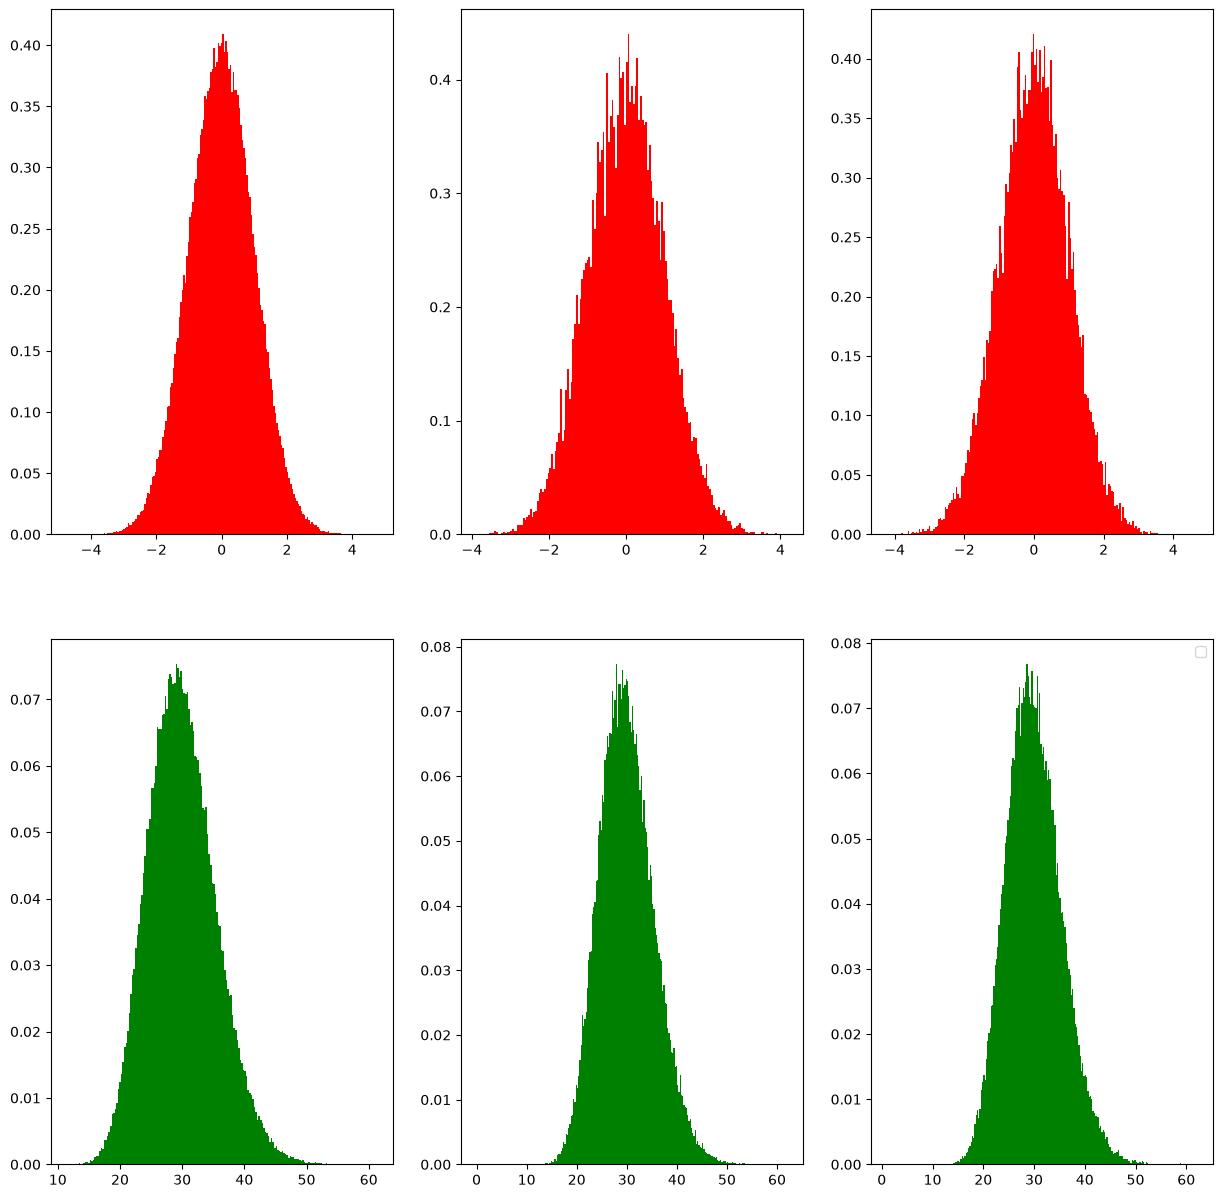

In [178]:
from functools import partial

distribs = [
    scipy.stats.norm(loc = 0, scale = 1), 
    scipy.stats.gamma(a = 30), 
] 

z0, z1, size, scale_lambda = 0, 1, 200000, 2 

def proposed_fn(z):
    return z + np.random.normal() * 10  

def scale_log_fn(fn, x): 
    return np.log(scale_lambda) + fn(x)

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(len(distribs), 3, squeeze=False, figsize = (15, 15))
for i in range(len(distribs)):
    axes[i, 0].hist(distribs[i].rvs(size = size), bins = 'auto', density = True, color = colors[i])
    axes[i, 1].hist(mcmc(z0, distribs[i].logpdf, proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    axes[i, 2].hist(mcmc(z1, partial(scale_log_fn, distribs[i].logpdf), proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    
plt.legend()
plt.show()

### Part 2: Tracking a position in 2D space 

The problem is to track the location distibution of a point in 2D array with 3 radars measure the Euclidean to the truth position
with some predefined deviation. 

Define $gamma$ as the density function of the point w.r.t 3 measures from those radars. 

$
   gamma(state) = \prod_1^3 p(state_euclidean_dist_i | measure_euclidean_dist_i)
$

with subtle assumption that each measure is independent for all radars. 

As the measure for radar_i has deviation sd, it means that the euclidean distance to i ~ $ N({measure_euclidean_dist_i}, sd)$ 

Hence, $p(state_euclidean_dist_i | measure_euclidean_dist_i)$ is calculate using the pdf of $ N({measure_euclidean_dist_i}, sd)$ 

We could use this gamma function as the function used ratio for transiting the state 

In [179]:
import math 
from scipy import stats 

def proposed_state(state):
    return state + np.random.normal(0, scale = move_sigmas)

def gamma_pdf_fn(state, radar_measures): 
    log_sum = 0 
    state_measures = np.linalg.norm(radar_locs - state, axis = 1) 
    for radar_id in range(len(radar_measures)):
        log_sum += stats.norm(
            loc = radar_measures[radar_id], 
            scale = radar_sigmas[radar_id]
        ).logpdf(state_measures[radar_id])
    
    return log_sum 



In [183]:
# set up
# unknown to us 
pos_truth = np.array([1,1]) 

# radar positions
radar_locs = [
    np.array([0, 0]), 
    np.array([10, 10]), 
    np.array([6, 3])
]

# the deviations of the measurements for each radars 
radar_sigmas = np.array([
    0.5, 
    0.1, 
    0.1 
])

# move sigma 
move_sigmas = np.array(
    [
        1, 
        1 
    ]
)

In [186]:
from functools import partial 

initial_state = np.array([2, 4])

# measure by radar with noise 
radar_measures = np.linalg.norm(radar_locs - pos_truth, axis=1) + np.random.normal(loc = 0, scale = radar_sigmas)
print("radar measure: ", radar_measures)

state_list = mcmc(initial_state, partial(gamma_pdf_fn, radar_measures = radar_measures), proposed_state, iters = 20000)

radar measure:  [ 0.24264618 12.71380476  5.40225522]


/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_33123/2123219377.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


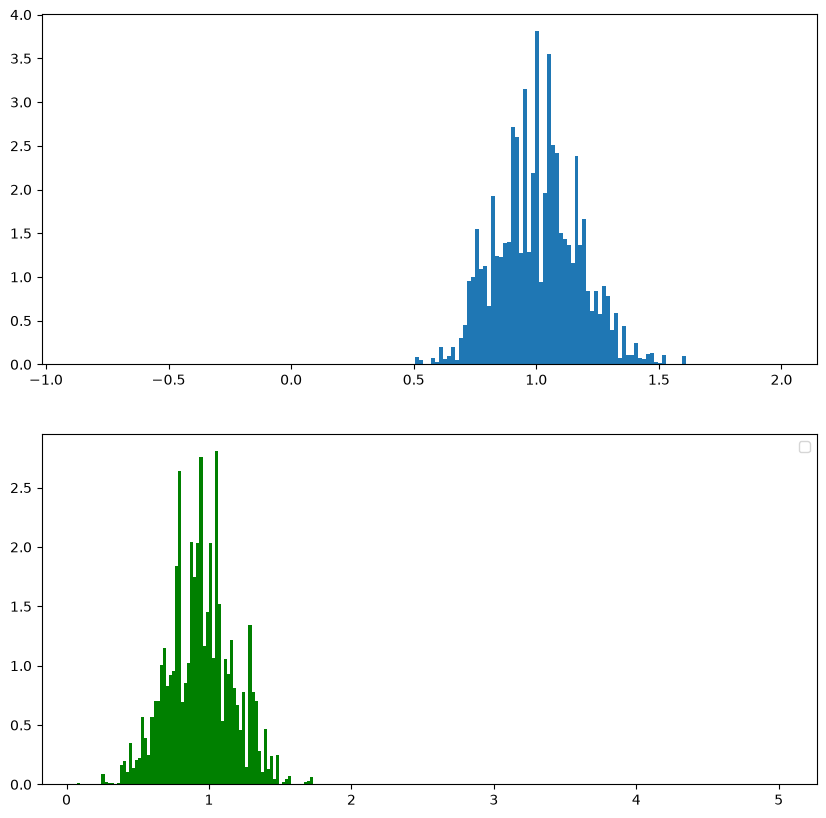

In [195]:
fig, ax = plt.subplots(2, 1, figsize = (10,10))
x = [state[0] for state in state_list]
y = [state[1] for state in state_list]

ax[0].hist(x, density = True, bins = 'auto')
ax[1].hist(y, density = True, bins = 'auto', color = 'green')

plt.legend()
plt.show()

#### As we can see the x and y distribution is quite near to the grouth truth value (1, 1) even though we start from (2, 4)